In [1]:
print(5)

5


In [2]:
# Cell 1: Verify environment
import sys
print(f"Python: {sys.version}")
print(f"Executable: {sys.executable}")
# Should point to something like /home/you/pypsa-eur/.pixi/envs/default/bin/python

import pypsa
print(f"PyPSA version: {pypsa.__version__}")

Python: 3.13.13 | packaged by conda-forge | (main, Apr  8 2026, 02:00:33) [GCC 14.3.0]
Executable: /home/ijs/python/pypsa-eur/.pixi/envs/default/bin/python
PyPSA version: 1.2.0


In [4]:
# Cell 2: Load the tutorial network
import pypsa
n = pypsa.Network("../results/test-elec/networks/base_s_6_elec_.nc")
n

INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores, sub_networks


PyPSA Network 'Unnamed Network'
-------------------------------
Components:
 - Bus: 12
 - Carrier: 18
 - Generator: 38
 - GlobalConstraint: 1
 - Line: 7
 - Link: 12
 - Load: 6
 - StorageUnit: 6
 - Store: 6
 - SubNetwork: 1
Snapshots: 7

In [5]:
# Cell 3: Inspect what's in it
print("Buses:")
print(n.buses[['country', 'x', 'y', 'carrier']])

print("\nGenerator capacities by carrier (MW):")
print(n.generators.groupby('carrier').p_nom.sum().round(1))

print("\nLoad sum (TWh/yr, scaled from snapshot resolution):")
total_mwh = (n.loads_t.p_set.sum(axis=1) * n.snapshot_weightings.objective).sum()
print(f"  {total_mwh / 1e6:.2f} TWh")

print(f"\nSnapshots: {len(n.snapshots)} from {n.snapshots[0]} to {n.snapshots[-1]}")
print(f"Snapshot resolution: {n.snapshot_weightings.objective.iloc[0]} hours")

Buses:
         country         x          y carrier
name                                         
BE0 0         BE  4.259513  51.253931      AC
BE0 1         BE  5.612993  50.472188      AC
BE0 2         BE  4.722477  50.501550      AC
BE0 3         BE  5.062711  51.107361      AC
BE0 4         BE  4.266435  50.711058      AC
BE0 5         BE  4.569019  51.156747      AC
BE0 0 H2      BE  4.259513  51.253931      H2
BE0 1 H2      BE  5.612993  50.472188      H2
BE0 2 H2      BE  4.722477  50.501550      H2
BE0 3 H2      BE  5.062711  51.107361      H2
BE0 4 H2      BE  4.266435  50.711058      H2
BE0 5 H2      BE  4.569019  51.156747      H2

Generator capacities by carrier (MW):
carrier
CCGT             6634.2
biomass           113.0
nuclear          4096.0
offwind-ac       2752.2
offwind-dc          0.0
offwind-float       0.0
oil               130.2
onwind           1724.0
solar             937.6
solar-hsat          0.0
waste             293.8
Name: p_nom, dtype: float64

Load sum 

/home/ijs/python/pypsa-eur/.pixi/envs/default/lib/python3.13/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_cultural/ne_50m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/home/ijs/python/pypsa-eur/.pixi/envs/default/lib/python3.13/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


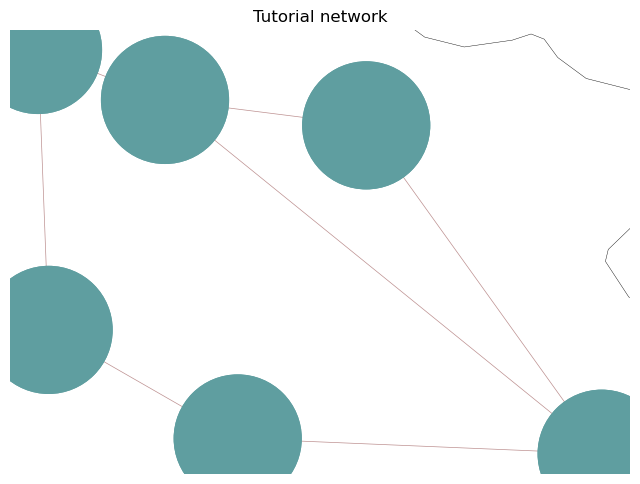

In [11]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

fig, ax = plt.subplots(
    figsize=(8, 8),
    subplot_kw={"projection": ccrs.EqualEarth()}
)
n.plot(
    ax=ax,
    bus_sizes=0.02,
    line_widths=0.5,
)
ax.set_title("Tutorial network")
plt.show()

In [8]:
# Cell 5: Check whether this is a solved or unsolved network
if 'p_nom_opt' in n.generators.columns and n.generators.p_nom_opt.sum() > 0:
    print("Network is SOLVED")
    print(f"Objective: {n.objective:,.0f} EUR")
    print(f"\nOptimal capacities by carrier (MW):")
    print(n.generators.groupby('carrier').p_nom_opt.sum().round(1))
else:
    print("Network is PREPARED but NOT SOLVED")
    print("Run: pixi run snakemake -call solve_elec_networks --configfile config/test/config.electricity.yaml")

Network is SOLVED
Objective: 50,015,029 EUR

Optimal capacities by carrier (MW):
carrier
CCGT              6634.2
biomass            113.0
nuclear           4096.0
offwind-ac        2752.2
offwind-dc           0.0
offwind-float        0.0
oil                130.2
onwind            1724.0
solar            38869.1
solar-hsat           0.2
waste              293.8
Name: p_nom_opt, dtype: float64


In [13]:
n_solved = n
print(f"Status: {n_solved.objective:,.0f} EUR")
print(n_solved.generators.groupby('carrier').p_nom_opt.sum().round(1))
print(n_solved.statistics.energy_balance().round(1))

Status: 50,015,029 EUR
carrier
CCGT              6634.2
biomass            113.0
nuclear           4096.0
offwind-ac        2752.2
offwind-dc           0.0
offwind-float        0.0
oil                130.2
onwind            1724.0
solar            38869.1
solar-hsat           0.2
waste              293.8
Name: p_nom_opt, dtype: float64
component    carrier                   bus_carrier     
Generator    Combined-Cycle Gas        AC                   245490.6
             Offshore Wind (AC)        AC                   141589.1
             Offshore Wind (DC)        AC                        0.1
             Offshore Wind (Floating)  AC                        0.0
             Onshore Wind              AC                    55623.9
             Solar                     AC                   846684.6
             biomass                   AC                    18983.4
             nuclear                   AC                   400370.4
             oil                       AC             